In [1]:

# Task 1 — Data Exploration with Pandas
# Load the dataset: df = pd.read_csv("students.csv")    

import pandas as pd

df = pd.read_csv("students.csv")

# 1. Print the first 5 rows using .head()
print(df.head())
print ()

# 2. Print the shape (rows × columns) and the data type of each column using .dtypes.
print(df.shape)
print(df.dtypes)
print ()

# 3. Print summary statistics (mean, min, max, std) for all numeric columns using .describe().
print(df.describe())
print ()

# 4. Print the count of students who passed and who failed. (Hint: use df['passed'].value_counts())
print(df['passed'].value_counts())
print ()

# 5. Compute and print the average score per subject (math, science, english, history, pe) separately for passing and failing students.
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average scores for passing students:")
print(df[df['passed'] == 1][subject_cols].mean())
print("\nAverage scores for failing students:")
print(df[df['passed'] == 0][subject_cols].mean())

# 6. Find and print the student with the highest overall average across all 5 subjects. 
df['overall_average'] = df[subject_cols].mean(axis=1)
print("\nStudent with the highest overall average:")
print(df.loc[df['overall_average'].idxmax()])





      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

            math    science    english    history         pe  attendance_pct  \
count  15.000000

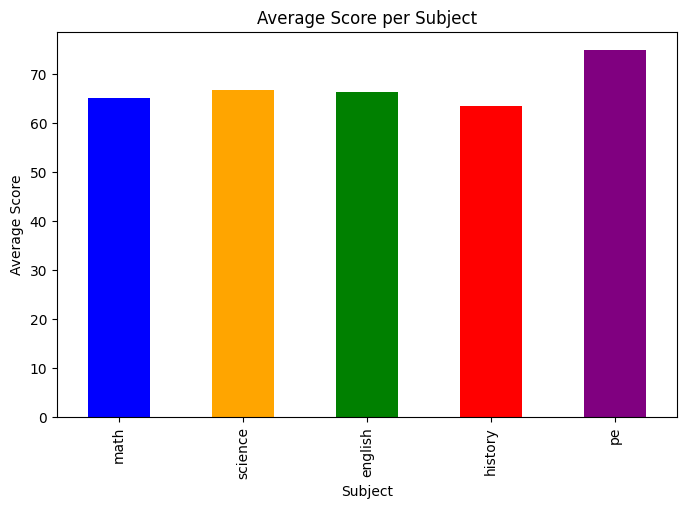

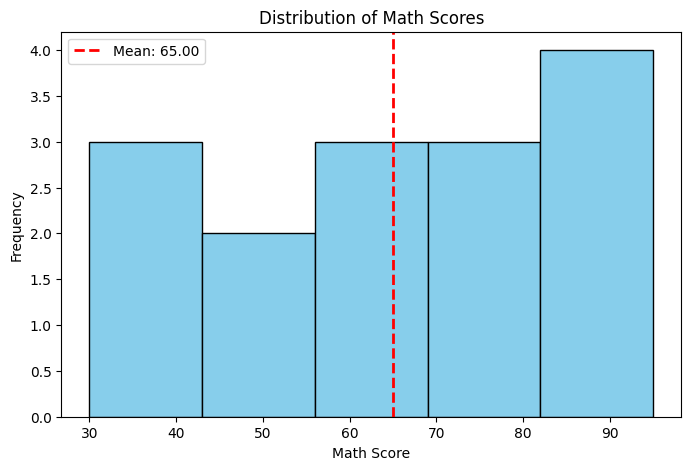

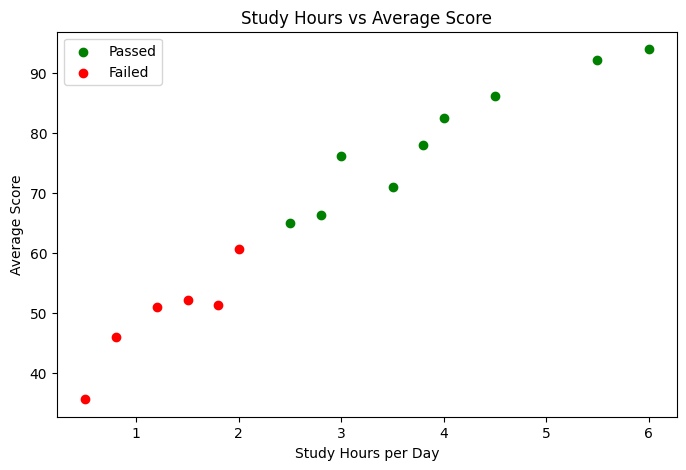

/var/folders/kh/hp1nlm8j22q6mc11vyrr6tsw0000gn/T/ipykernel_19331/3805173359.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Passed', 'Failed'])


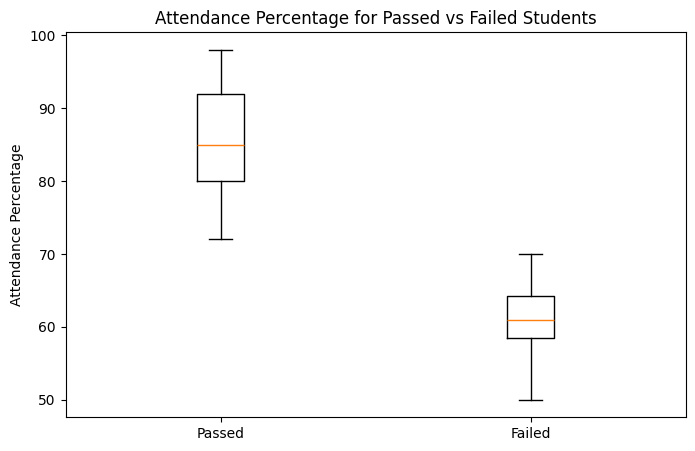

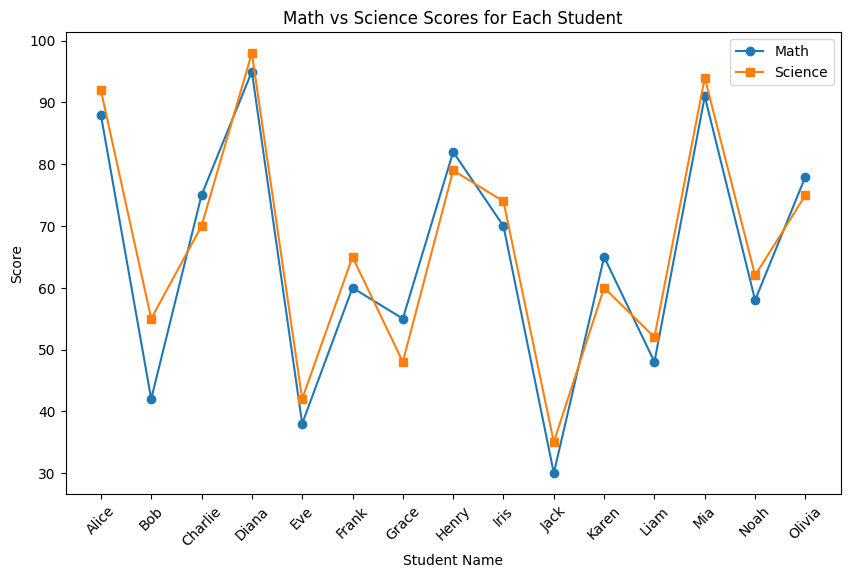

In [2]:

# Task 2 - Data Visualization with Matplotlib
# Before starting, add a new column to your DataFrame:
# subject_cols = ['math', 'science', 'english', 'history', 'pe']
# df['avg_score'] = df[subject_cols].mean(axis=1)
import matplotlib.pyplot as plt
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# You will use df['avg_score'] in the scatter plot below.
# Produce the following 5 plots. Each must have a descriptive title, labelled axes, and a legend where applicable. Save each plot as a .png file (e.g., plot1_bar.png) and display it inline.

# 1. Bar Chart — Average score per subject across all students (one bar per subject, x-axis = subject name, y-axis = average score).
avg_scores = df[subject_cols].mean()
plt.figure(figsize=(8, 5))
avg_scores.plot(kind='bar', color=['blue', 'orange', 'green', 'red', 'purple'])
plt.title('Average Score per Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.savefig('plot1_bar.png')
plt.show()

# 2. Histogram — Distribution of math scores. Use 5 bins. Add a vertical dashed line at the mean math score and label it.
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='skyblue', edgecolor='black')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["math"].mean():.2f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('plot2_histogram.png')
plt.show()

# 3. Scatter Plot — study_hours_per_day (x-axis) vs avg_score (y-axis). Colour each point differently based on passed: one colour for Pass, another for Fail. Include a legend.
plt.figure(figsize=(8, 5))
plt.scatter(df[df['passed'] == 1]['study_hours_per_day'], df[df['passed'] == 1]['avg_score'], color='green', label='Passed')
plt.scatter(df[df['passed'] == 0]['study_hours_per_day'], df[df['passed'] == 0]['avg_score'], color='red', label='Failed')
plt.title('Study Hours vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.savefig('plot3_scatter.png')
plt.show()

# 4. Box Plot — Show the distribution of attendance_pct for passing students vs failing students side by side.
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Passed', 'Failed'])
plt.title('Attendance Percentage for Passed vs Failed Students')
plt.ylabel('Attendance Percentage')
plt.savefig('plot4_boxplot.png')
plt.show()

# 5. Line Plot — Plot the math score and science score for every student. X-axis = student name, Y-axis = score. 
plt.figure(figsize=(10, 6))
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.title('Math vs Science Scores for Each Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.legend()
plt.xticks(rotation=45)
plt.savefig('plot5_line.png')
plt.show()




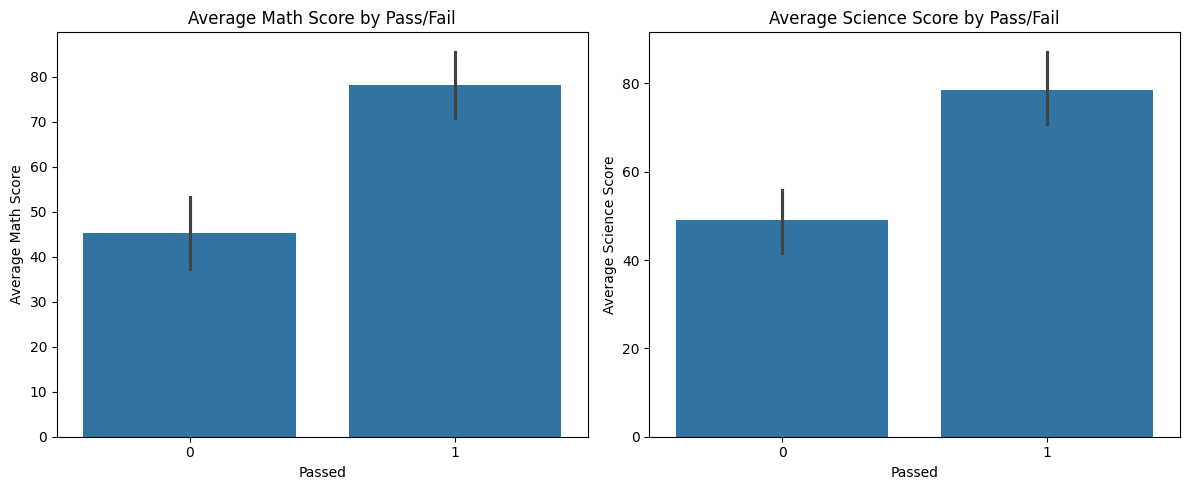

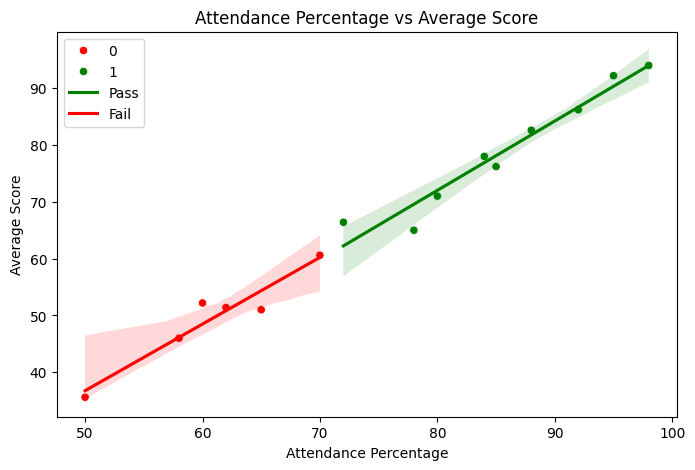

In [3]:

# Task 3 - Data Visualization with Seaborn

# 1. Create a Seaborn bar plot showing the average math score and average science score, split by passed (Pass vs Fail).
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xlabel('Passed')
ax1.set_ylabel('Average Math Score')

ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xlabel('Passed')
ax2.set_ylabel('Average Science Score')

plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')
plt.show()

# 2. Create a Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis), coloured by passed.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', palette={1: 'green', 0: 'red'})
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass', color='green')
sns.regplot(data=df[df['passed'] == 0
], x='attendance_pct', y='avg_score', scatter=False, label='Fail', color='red')
plt.title('Attendance Percentage vs Average Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Average Score')
plt.legend()
plt.savefig('plot7_seaborn_scatter.png')
plt.show()

# 3. Save both Seaborn plots as .png files.
# handled above

# 4. Write 2–3 sentences as a comment in your code comparing your experience of using Seaborn vs Matplotlib for these plots 

# Seaborn required less code to produce cleaner, visually appealing plots, especially for the bar plot - which automatically
# grouped data by 'Passed' without any manual filtering unlike Matplotlib where I had to separately filter passing and failing students.
# However, Matplotlib gave me more control - e.g; I manually customised bar colours and added a dashed mean line in the histogram, which felt more hands-on.
# Overall, Seaborn was quicker for statistical plots while Matplotlib was better for custom, more precise visualizations.


Training Accuracy: 1.00
Test Accuracy: 1.00
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅

Feature Importance (Coefficient Values):
math: 0.4379
science: 0.3230
english: 0.8125
history: 0.2629
pe: 0.4750
attendance_pct: 0.5219
study_hours_per_day: 0.4844

Features sorted by importance:
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


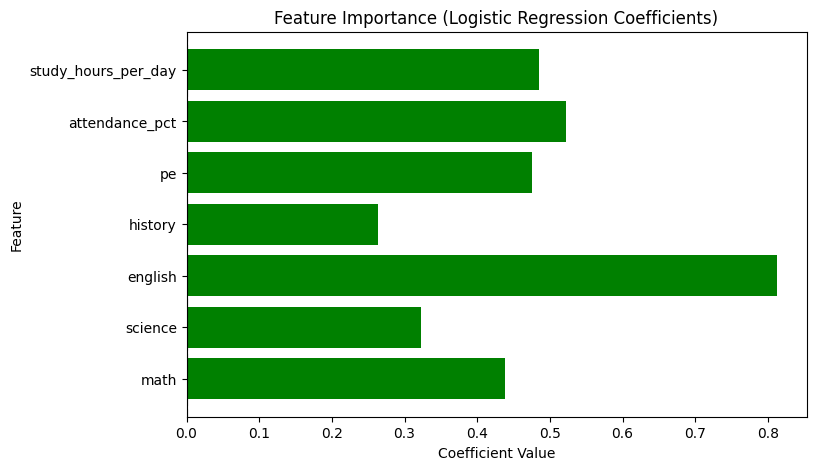

New student prediction: Pass (Probability: 0.91)


In [4]:
# Task 4 - Machine Learning with scikit-learn

# Build a classifier to predict whether a student will pass or fail.

# Features (X): math, science, english, history, pe, attendance_pct, study_hours_per_day
# Target (y): passed

# Step 1 — Prepare Data:

# Separate features and target. Keep the original df intact (do not drop the name column from df — only exclude it from X).
# Split into train (80%) and test (20%) sets:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.model_selection import train_test_split
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler — fit on training data only, then transform both sets:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 2 - Train a Model:
# 1. Train a LogisticRegression model on the scaled training data.
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 2. Print the model's training accuracy.
train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy:.2f}")

# Step 3 - Evaluate the Model:

# 1. Predict on the test set.
y_pred = model.predict(X_test_scaled)

# 2. Print the test accuracy.
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# 3. For each student in the test set, print their name alongside the actual label and predicted label, and whether the prediction was ✅ correct or ❌ wrong.
test_names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(test_names, y_test, y_pred):
    correctness = "✅" if actual == pred else "❌"
    print(f"{name}: Actual={actual}, Predicted={pred} {correctness}")

# Step 4 - Feature Importance:

# 1. Extract the model coefficients: model.coef_[0] — these are one value per feature.
feature_importance = model.coef_[0]
feature_names = X.columns
importance_dict = dict(zip(feature_names, feature_importance))
print("\nFeature Importance (Coefficient Values):")
for feature, importance in importance_dict.items():
    print(f"{feature}: {importance:.4f}")


# 2. Pair each coefficient with its feature name and print them, sorted by absolute value (largest first).
sorted_importance = sorted(importance_dict.items(), key=lambda x: abs(x[1]), reverse=True)
print("\nFeatures sorted by importance:")
for feature, importance in sorted_importance:
    print(f"{feature}: {importance:.4f}")

# 3. Create a horizontal bar chart using Matplotlib showing all feature coefficients. Use different colours for positive (green) and negative (red) coefficients. 
# Add a title and axis labels.
# A positive coefficient means that feature pushes the prediction towards Pass; a negative one pushes towards Fail.
plt.figure(figsize=(8, 5))
colors = ['green' if imp > 0 else 'red' for imp in feature_importance]
plt.barh(feature_names, feature_importance, color=colors)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linestyle='--')
plt.savefig('feature_importance.png')
plt.show()

# Step 5 - Predict for a New Student
# Define a new student with values of your choice:

# new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order must match feature columns
# Scale it using scaler.transform(new_student) and predict using model.predict(). Print whether the model predicts Pass or Fail, and display the probability using model.predict_proba().

import pandas as pd
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day'])
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0][prediction]
result = "Pass" if prediction == 1 else "Fail"
print(f"New student prediction: {result} (Probability: {probability:.2f})")
    

